In [1]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
import PcmPy as pcm
from EFC_learningfMRI.util import get_trained_and_untrained
from EFC_learningfMRI.pcm import make_models

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
H = 'L'
atlas = 'ROI'
rois = gl.rois[atlas]
glm = 3

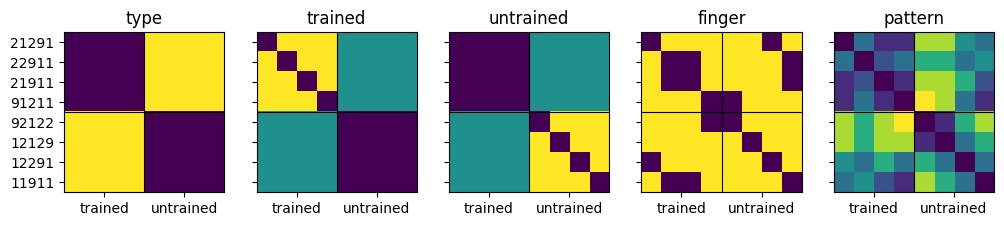

In [3]:
sn = 104
M, comp_names = make_models(sn)
Mc = M[-2]

trained_untrained = get_trained_and_untrained(sn)

fig, axs = plt.subplots(1, Mc.Gc.shape[0], sharex=True, sharey=True, figsize=(12, 4))

for i, G in enumerate(Mc.Gc):
    ax = axs[i]
    d = pcm.G_to_dist(G)
    im = ax.imshow(d)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(trained_untrained)
    ax.set_title(comp_names[i])

plt.show()

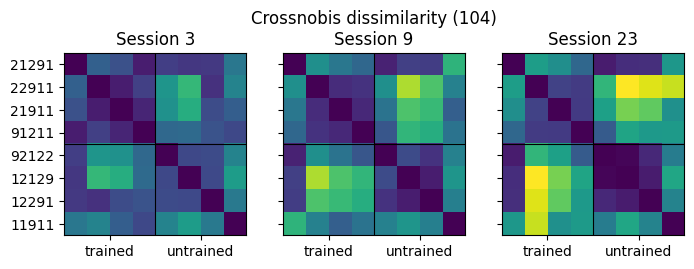

In [4]:
roi = 'SPLa'
G = np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}', f'G_obs.{H}.{roi}.npy'))
D = pcm.G_to_dist(G)

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(8, 4))

vmin, vmax = 0, D.max()

for i in range(D.shape[0]):
    ax = axs[i]
    im = ax.imshow(D[i], vmin=vmin, vmax=vmax)
    ax.set_title(f'Crossnobis dissimilarity ({sn})\nSession {gl.sessions[i]}') if i==1 else ax.set_title(f'Session {gl.sessions[i]}')
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(trained_untrained)

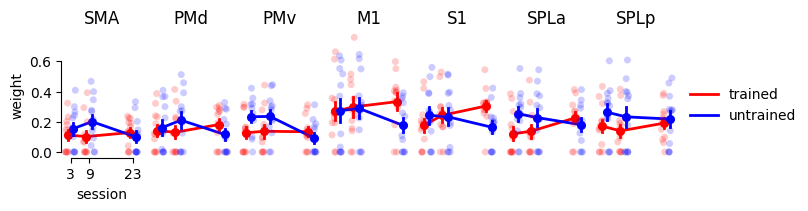

In [5]:
comp_names = ['type', 'trained', 'untrained', 'finger', 'pattern'] 
comp_model = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'component_model.{atlas}.glm{glm}.tsv'), sep='\t')
N = comp_model.sn.nunique()

# divide all components by the noise component within each subject/roi/session/hemisphere
keys = ['sn', 'roi', 'sess', 'Hem']
noise = comp_model[comp_model.component=='noise'][keys + ['weight']].rename(columns={'weight': 'noise'})
comp_model = comp_model.merge(noise, on=keys)
comp_model['weight_norm'] = np.sqrt(comp_model['weight'] / comp_model['noise'])
comp_model = comp_model[(comp_model.component!='noise') & (comp_model.Hem==H)]

hue_order = ['trained', 'untrained']
palette = ['red', 'blue']

comp_model_tr_untr = comp_model[comp_model.component.isin(hue_order)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, comp_model_tr_untr, rois, y='weight_norm', x='sess', hue='component', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.3)
plot_im_sess(fig, axs, comp_model_tr_untr, rois, y='weight_norm', x='sess', hue='component', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].get_legend().remove()
custom_legend(fig, labels=hue_order, colors=palette, kind='point')
axs[0].set_xlabel('session')

plt.show()

Text(0.5, 0, 'session')

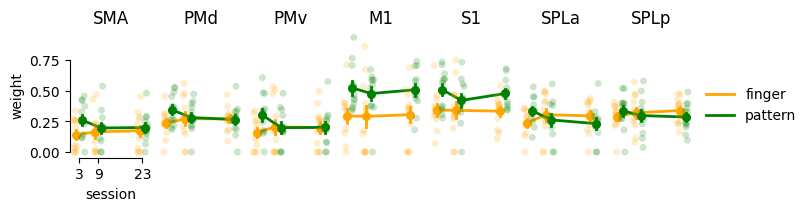

In [6]:
hue_order = ['finger', 'pattern']
palette = ['orange', 'green']

comp_model_repr = comp_model[comp_model.component.isin(hue_order)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, comp_model_repr, rois, y='weight_norm', x='sess', hue='component', hue_order=hue_order, palette=palette, kind='point', dodge=.3)
plot_im_sess(fig, axs, comp_model_repr, rois, y='weight_norm', x='sess', hue='component', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].get_legend().remove()
custom_legend(fig, labels=hue_order, colors=palette, kind='point')
axs[0].set_xlabel('session')